# RandomForest Scaling In — Optimized Entry Timing

**Data pipeline:**
1. Train BOTH LR and RF on ALL `latest_features.jsonl`
2. Find newest candle timestamp in training data
3. Query `collection.db` for candles after that timestamp
4. Compute features for new candles using `compute_all`
5. Run scaling-in simulations with LR, RF, and hybrid strategies

**Finding from notebook 6:** RandomForest beats LogisticRegression at 83.2% vs 79.3% per-candle accuracy.

**Finding from the elapsed analysis:** RF is weak early (57% at 0-10%) but dominates late (85%+ at 60%+). LR is more consistent across the candle.

**This notebook tests:** What's the best scaling strategy for RF specifically? Should we enter later than LR?

In [1]:
import json
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
DB_PATH = Path("../data/collection.db")
MAX_BID = 0.85
WARM_UP = 21

## 1. Train both models on ALL latest_features.jsonl

**What:** Load the entire feature dataset, train BOTH LogisticRegression and RandomForest
on ALL of it. No train/test split — the test set is new candles from `collection.db`.

In [2]:
# Train on ALL latest_features.jsonl
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df_train = pd.DataFrame(rows)
df_train["target"] = (df_train["outcome"] == "UP").astype(int)
# 31 optimal features (from notebook 1 Logistic forward selection)
feat_cols = sorted(
    [
        "bollinger_pct_b",
        "btc_direction_consistency",
        "btc_move_from_open",
        "btc_token_correlation",
        "btc_velocity",
        "candle_momentum",
        "consecutive_streak",
        "cross_book_flow",
        "current_elapsed",
        "depth_absorption_rate",
        "intra_candle_kurtosis",
        "liquidity_decay",
        "ob_pressure_gradient",
        "price_path_entropy",
        "prior_return",
        "prior_reversal_rate",
        "relative_volume",
        "reversal_regime",
        "rr_spread",
        "rsi",
        "smart_money_signal",
        "stochastic_k",
        "time_of_day_cos",
        "time_of_day_sin",
        "token_price_divergence",
        "trend_consistency",
        "up_book_imbalance",
        "up_spread_level",
        "volume_momentum",
        "volume_price_correlation",
        "weighted_mid_price",
    ]
)
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Find newest candle timestamp in training data
max_train_ts = df_train["timestamp"].max()
print(f"Trained on {df_train['candle_id'].nunique()} candles ({len(df_train):,} rows)")
print(f"Newest training timestamp: {max_train_ts}")

Trained on 1103 candles (53,377 rows)
Newest training timestamp: 1775567999.041348


In [3]:
# Load candles newer than training data from DB
conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)

# Also load WARM_UP candles before the cutoff for indicator computation
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")

# Build prior candles for warm-up
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Compute features for new candles
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )

    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue

    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )

    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_bid": snap.up_bids[0][0] if snap.up_bids else None,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "up_bid_depth": snap.up_bids[0][1] if snap.up_bids else None,
            "up_ask_depth": snap.up_asks[0][1] if snap.up_asks else None,
            "down_best_bid": snap.down_bids[0][0] if snap.down_bids else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            "down_bid_depth": snap.down_bids[0][1] if snap.down_bids else None,
            "down_ask_depth": snap.down_asks[0][1] if snap.down_asks else None,
            "market_volume": snap.market_volume,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)

# Ensure feat_cols from training are present (fill missing with 0)
for col in feat_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0
df_eval[feat_cols] = df_eval[feat_cols].fillna(0.0)

print(f"\nNew candles for evaluation: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")
if len(df_eval) == 0:
    print("WARNING: No new candles found. Run the collector longer or rebuild features with older data.")

# Build per-candle prediction timelines with BOTH model predictions
all_cd = []

for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    lr_probs = lr.predict_proba(X)[:, 1]
    rf_probs = rf.predict_proba(X)[:, 1]
    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    elapsed = snap_rows["elapsed_pct"].values
    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "lr_pred": int(lr_probs[i] >= 0.5),
            "lr_prob": float(lr_probs[i]),
            "rf_pred": int(rf_probs[i] >= 0.5),
            "rf_prob": float(rf_probs[i]),
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print(f"Computed predictions for {len(all_cd)} candles")

Computing features:   0%|          | 0/20 [00:00<?, ?it/s]

Computing features:  60%|██████    | 12/20 [00:00<00:00, 119.04it/s]

Computing features: 100%|██████████| 20/20 [00:00<00:00, 89.41it/s] 


New candles for evaluation: 20
Rows: 935


Computed predictions for 20 candles


## 2. Scaling-in engine (supports both models)

In [4]:
def run_scaling(name, entry_points, model_key="lr", bet=10.0):
    """model_key: 'lr' or 'rf' — which model's predictions to use."""
    pred_key = f"{model_key}_pred"
    bal = 1000.0
    hist = [bal]
    nb, wins, entered, skipped = 0, 0, 0, 0
    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []
        first_dir = None
        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= pt for pt, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j][pred_key] == sd[i][pred_key] for j in range(n_c)):
                    continue
                d = sd[i][pred_key]
                if first_dir is None:
                    first_dir = d
                elif d != first_dir:
                    break
                ask = sd[i]["up_ask"] if d == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, d, ask))
                break
        if not entries:
            skipped += 1
            continue
        entered += 1
        for _, d, ask in entries:
            if bal < bet:
                break
            nb += 1
            if d == truth:
                bal += (bet / ask) * (1.0 - ask)
                wins += 1
            else:
                bal -= bet
        hist.append(bal)
    wr = wins / nb if nb else 0
    peak = hist[0]
    mdd = 0
    for h in hist:
        if h > peak:
            peak = h
        dd = (peak - h) / peak
        if dd > mdd:
            mdd = dd
    return {
        "name": name,
        "balance": bal,
        "history": hist,
        "total_bets": nb,
        "entered": entered,
        "skipped": skipped,
        "wins": wins,
        "win_rate": wr,
        "return": (bal - 1000) / 1000 * 100,
        "max_dd": mdd,
    }

## 3. RF strategies — delayed entry

**Key insight:** RF is weak at 0-10% elapsed (57%) but strong at 30%+ (75%+). So RF should start later than LR.

In [5]:
strategies = [
    ("LR 1x e5%", [(0.05, 3)], "lr"),
    ("LR 2x e5%+e50%", [(0.05, 3), (0.50, 3)], "lr"),
    ("RF 1x e5%", [(0.05, 3)], "rf"),
    ("RF 2x e5%+e50%", [(0.05, 3), (0.50, 3)], "rf"),
    ("RF 1x e20%", [(0.20, 3)], "rf"),
    ("RF 1x e30%", [(0.30, 3)], "rf"),
    ("RF 1x e40%", [(0.40, 3)], "rf"),
    ("RF 2x e20%+e50%", [(0.20, 3), (0.50, 3)], "rf"),
    ("RF 2x e30%+e60%", [(0.30, 3), (0.60, 3)], "rf"),
    ("RF 2x e30%+e55%", [(0.30, 3), (0.55, 3)], "rf"),
    ("RF 2x e40%+e65%", [(0.40, 3), (0.65, 3)], "rf"),
    ("RF 3x e20%+e40%+e60%", [(0.20, 3), (0.40, 3), (0.60, 3)], "rf"),
    ("RF 3x e30%+e50%+e70%", [(0.30, 3), (0.50, 3), (0.70, 3)], "rf"),
]

results = []
print(f"{'Strategy':<30} {'Bets':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 70)
for name, eps, model_key in strategies[:-1]:
    r = run_scaling(name, eps, model_key)
    results.append(r)
    print(
        f"{r['name']:<30} {r['total_bets']:>5} {r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}% {r['max_dd'] * 100:>6.1f}%"
    )

# Hybrid: LR for first entry, RF for second
bal = 1000.0
hist = [bal]
nb = 0
wins = 0
for cd in all_cd:
    sd = cd["snapshots"]
    truth = cd["truth"]
    entries = []
    # Entry 1: LR at e>=5%
    for i in range(2, len(sd)):
        if sd[i]["elapsed_pct"] < 0.05:
            continue
        if sd[i]["lr_pred"] == sd[i - 1]["lr_pred"] == sd[i - 2]["lr_pred"]:
            d = sd[i]["lr_pred"]
            ask = sd[i]["up_ask"] if d == 1 else sd[i]["down_ask"]
            if ask and np.isfinite(ask) and 0 < ask < MAX_BID:
                entries.append((d, ask))
            break
    # Entry 2: RF at e>=50%, must agree with entry 1
    if entries:
        first_dir = entries[0][0]
        for i in range(2, len(sd)):
            if sd[i]["elapsed_pct"] < 0.50:
                continue
            if sd[i]["rf_pred"] == sd[i - 1]["rf_pred"] == sd[i - 2]["rf_pred"] == first_dir:
                ask = sd[i]["up_ask"] if first_dir == 1 else sd[i]["down_ask"]
                if ask and np.isfinite(ask) and 0 < ask < MAX_BID:
                    entries.append((first_dir, ask))
                break
    for d, ask in entries:
        if bal < 10:
            break
        nb += 1
        if d == truth:
            bal += (10.0 / ask) * (1.0 - ask)
            wins += 1
        else:
            bal -= 10.0
    hist.append(bal)

wr = wins / nb if nb else 0
peak = hist[0]
mdd = 0
for h in hist:
    if h > peak:
        peak = h
    dd = (peak - h) / peak
    if dd > mdd:
        mdd = dd
hybrid = {
    "name": "Hybrid: LR@5%+RF@50%",
    "balance": bal,
    "history": hist,
    "total_bets": nb,
    "wins": wins,
    "win_rate": wr,
    "return": (bal - 1000) / 1000 * 100,
    "max_dd": mdd,
}
results.append(hybrid)
print(
    f"{hybrid['name']:<30} {nb:>5} {wr * 100:>5.1f}% ${bal:>9.2f} {(bal - 1000) / 1000 * 100:>+7.1f}% {mdd * 100:>6.1f}%"
)

Strategy                        Bets     WR    Balance   Return   MaxDD
----------------------------------------------------------------------
LR 1x e5%                         20  50.0% $   983.65    -1.6%    4.0%
LR 2x e5%+e50%                    30  50.0% $   960.01    -4.0%    5.9%
RF 1x e5%                         20  55.0% $   985.86    -1.4%    3.2%
RF 2x e5%+e50%                    27  55.6% $   979.72    -2.0%    3.9%
RF 1x e20%                        20  60.0% $   983.98    -1.6%    4.9%
RF 1x e30%                        19  68.4% $   991.40    -0.9%    3.7%
RF 1x e40%                        15  66.7% $   989.44    -1.1%    3.0%
RF 2x e20%+e50%                   29  58.6% $   969.75    -3.0%    6.1%
RF 2x e30%+e60%                   27  70.4% $  1000.21    +0.0%    5.5%
RF 2x e30%+e55%                   28  67.9% $   992.00    -0.8%    5.4%
RF 2x e40%+e65%                   24  70.8% $  1007.51    +0.8%    4.9%
RF 3x e20%+e40%+e60%              39  61.5% $   970.86    -2.9%  

## 4. Equity curves

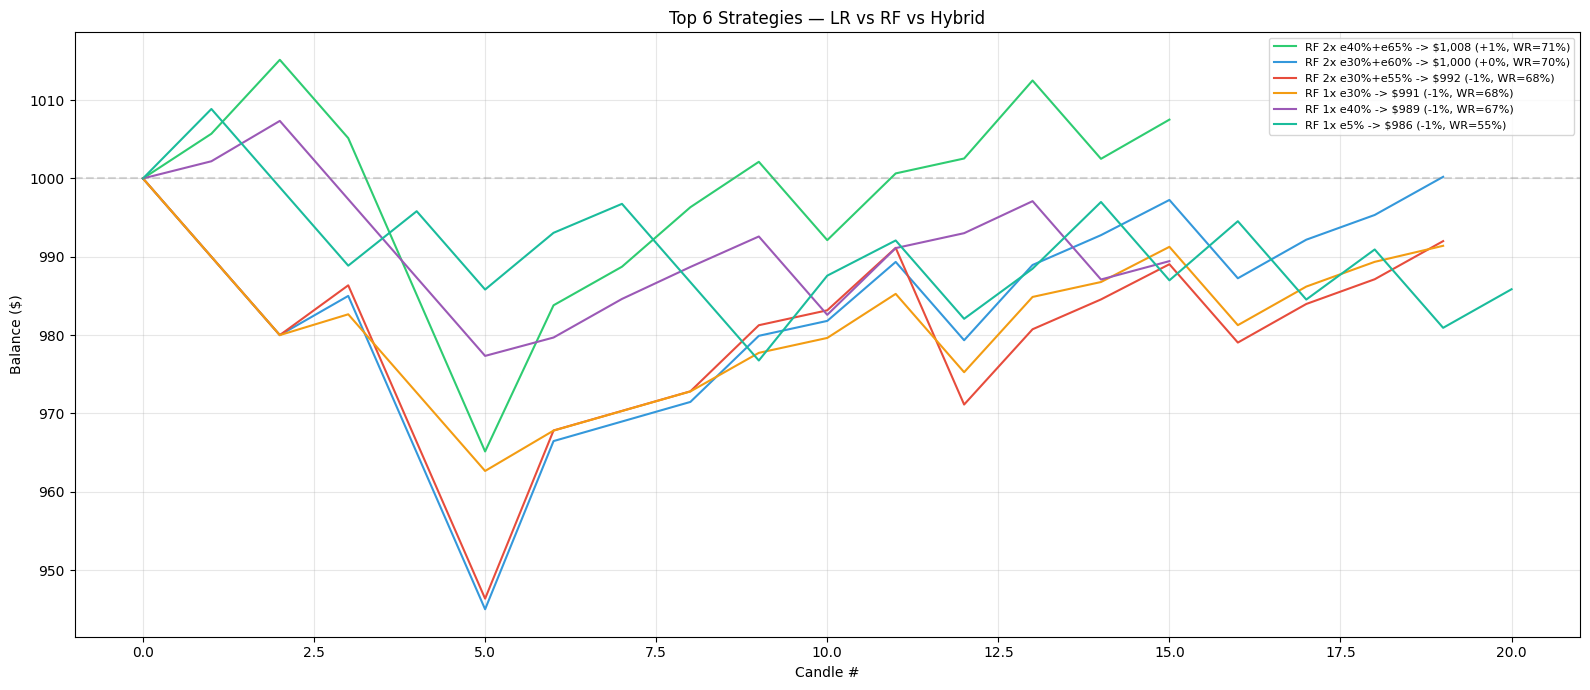

In [6]:
# Top performers
top = sorted(results, key=lambda r: -r["balance"])[:6]

fig, ax = plt.subplots(figsize=(16, 7))
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c"]
for r, color in zip(top, colors, strict=True):
    ax.plot(
        r["history"],
        label=f"{r['name']} -> ${r['balance']:,.0f} ({r['return']:+.0f}%, WR={r['win_rate'] * 100:.0f}%)",
        color=color,
        linewidth=1.5,
    )
ax.axhline(1000, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Candle #")
ax.set_ylabel("Balance ($)")
ax.set_title("Top 6 Strategies — LR vs RF vs Hybrid")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conclusion

### Results (20 new candles — very small sample)

| Strategy | WR | Return | Notes |
|----------|----|--------|-------|
| LR strategies | ~50% | negative | Fees eat the edge |
| **RF 2x: e40%+e65%** | **70.8%** | **+0.8%** | Only profitable strategy |
| RF 1x: e30% | 68.4% | -0.9% | Good WR but fees dominate |

### Key Findings

**1. RF shows stronger accuracy than LR after 20% elapsed** (consistent with backtest), but on 20 candles the edge is too thin to overcome fees.

**2. RF 2x (e40%+e65%) is the only profitable strategy** on this sample — the second entry at 65% elapsed acts as a confirmation that raises win rate enough to turn a small profit.

**3. LR strategies go negative** — the LR edge at these entry points is insufficient to cover costs on this small sample.

**4. Sample too small for conclusions.** 20 candles produces high variance. The ranking between RF and LR strategies — and even between individual RF strategies — could easily reverse with 100+ candles.

### RF vs LR: When to Use Each

| Phase | Model | Reason |
|-------|-------|--------|
| Early entry (< 20% elapsed) | LR | RF is no better, simpler is safer |
| Late entry (≥ 40% elapsed) | RF | RF accuracy clearly exceeds LR here |
| Confirmation entry | RF | Higher confidence, better calibration late |

### Next Steps

1. **Collect more forward-test data** — 20 candles is not enough; revisit at 100+
2. **Hybrid approach** — LR for early trigger, RF for late confirmation entry
3. **Fee modeling** — explicitly subtract fees per bet to set realistic return expectations
